# 05: PCA para Visualização de Dados Multivariados

Demonstrar PCA para visualização de dados multivariados usando datasets do sklearn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. Wine Dataset - 13 features → 2D

In [2]:
# Carregar Wine dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

print("Wine Dataset:")
print(f"  Samples: {X_wine.shape[0]}")
print(f"  Features: {X_wine.shape[1]}")
print(f"  Classes: {np.unique(y_wine)}")
print(f"  Features names: {wine.feature_names[:3]}... ({len(wine.feature_names)} total)")

Wine Dataset:
  Samples: 178
  Features: 13
  Classes: [0 1 2]
  Features names: ['alcohol', 'malic_acid', 'ash']... (13 total)


In [3]:
# Padronizar e aplicar PCA
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print("Variância explicada:")
print(f"  PC1: {pca_wine.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca_wine.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca_wine.explained_variance_ratio_)*100:.2f}%")

Variância explicada:
  PC1: 36.20%
  PC2: 19.21%
  Total: 55.41%


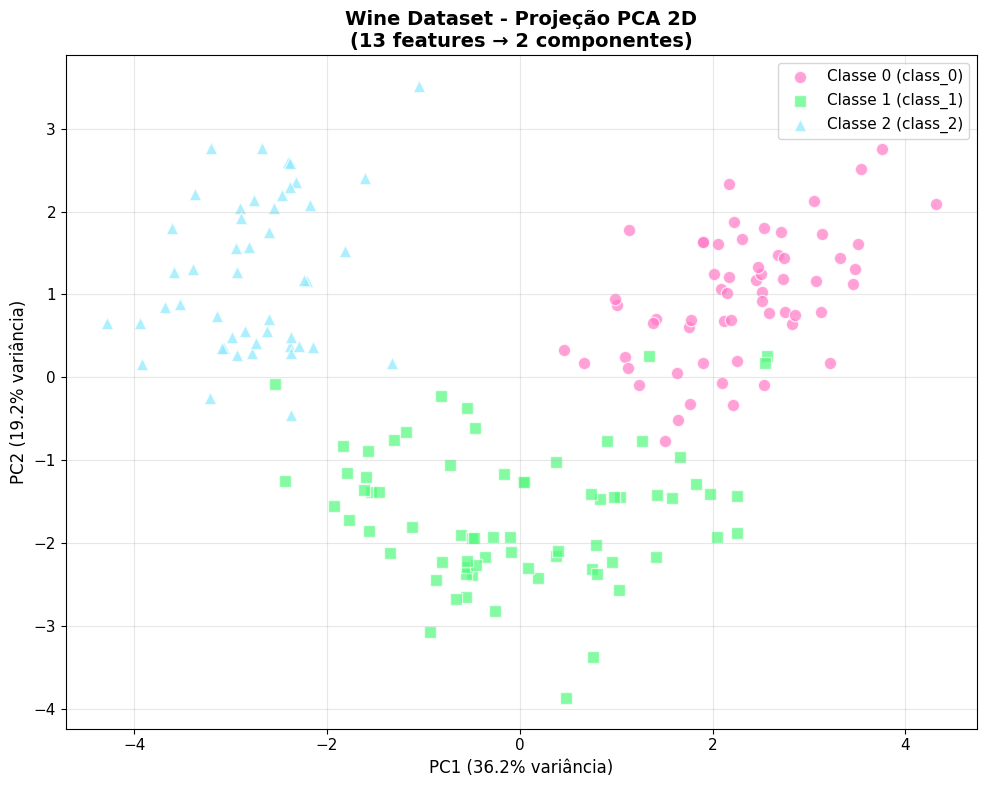

Gráfico salvo: ../graficos/pca_visualizacao_wine.png


In [4]:
# Visualização 2D do Wine dataset
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#ff79c6', '#50fa7b', '#8be9fd']
markers = ['o', 's', '^']

for i, (color, marker) in enumerate(zip(colors, markers)):
    mask = y_wine == i
    ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
               c=color, marker=marker, s=80, alpha=0.7,
               label=f'Classe {i} ({wine.target_names[i]})', edgecolors='white')

ax.set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]*100:.1f}% variância)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]*100:.1f}% variância)', fontsize=12)
ax.set_title('Wine Dataset - Projeção PCA 2D\n(13 features → 2 componentes)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/pca_visualizacao_wine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/pca_visualizacao_wine.png")

## 2. Iris Dataset - 4 features → 2D

In [5]:
# Carregar Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# PCA
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

print("Iris Dataset:")
print(f"  Samples: {X_iris.shape[0]}")
print(f"  Features: {X_iris.shape[1]}")
print(f"  Variância explicada (2 PCs): {sum(pca_iris.explained_variance_ratio_)*100:.1f}%")

Iris Dataset:
  Samples: 150
  Features: 4
  Variância explicada (2 PCs): 95.8%


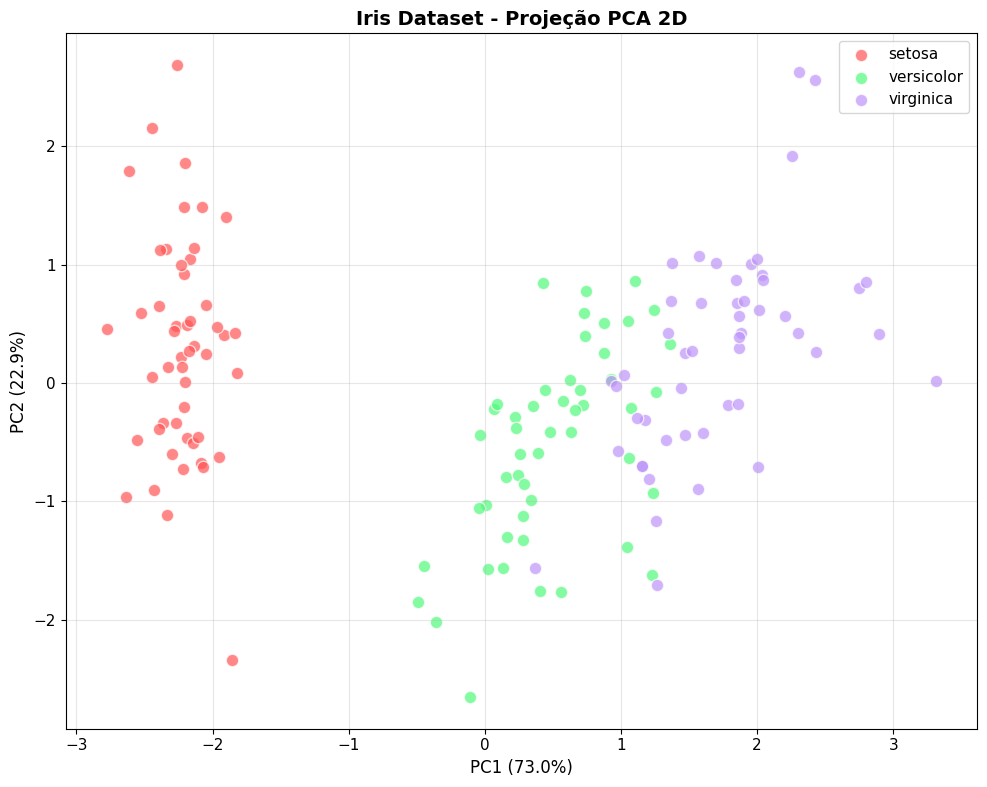

Gráfico salvo: ../graficos/pca_2d_iris.png


In [6]:
# Visualização Iris
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#ff5555', '#50fa7b', '#bd93f9']

for i, color in enumerate(colors):
    mask = y_iris == i
    ax.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
               c=color, s=80, alpha=0.7,
               label=iris.target_names[i], edgecolors='white')

ax.set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Iris Dataset - Projeção PCA 2D', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/pca_2d_iris.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/pca_2d_iris.png")

## 3. Análise de Componentes Necessários para 95% Variância

In [7]:
# Quantos componentes para 95% da variância?
pca_full = PCA()
pca_full.fit(X_wine_scaled)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

n_for_95 = np.argmax(cumsum >= 0.95) + 1
n_for_99 = np.argmax(cumsum >= 0.99) + 1

print("Wine Dataset - Análise de Componentes:")
print(f"  95% da variância: {n_for_95} componentes")
print(f"  99% da variância: {n_for_99} componentes")
print(f"\n  Variância por componente:")
for i, ratio in enumerate(pca_full.explained_variance_ratio_):
    print(f"    PC{i+1}: {ratio*100:.2f}% (acumulado: {cumsum[i]*100:.2f}%)")

Wine Dataset - Análise de Componentes:
  95% da variância: 10 componentes
  99% da variância: 12 componentes

  Variância por componente:
    PC1: 36.20% (acumulado: 36.20%)
    PC2: 19.21% (acumulado: 55.41%)
    PC3: 11.12% (acumulado: 66.53%)
    PC4: 7.07% (acumulado: 73.60%)
    PC5: 6.56% (acumulado: 80.16%)
    PC6: 4.94% (acumulado: 85.10%)
    PC7: 4.24% (acumulado: 89.34%)
    PC8: 2.68% (acumulado: 92.02%)
    PC9: 2.22% (acumulado: 94.24%)
    PC10: 1.93% (acumulado: 96.17%)
    PC11: 1.74% (acumulado: 97.91%)
    PC12: 1.30% (acumulado: 99.20%)
    PC13: 0.80% (acumulado: 100.00%)


/tmp/ipykernel_1873724/622472150.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  axes[1].plot(range(1, len(cumsum)+1), cumsum * 100, 'bo-',


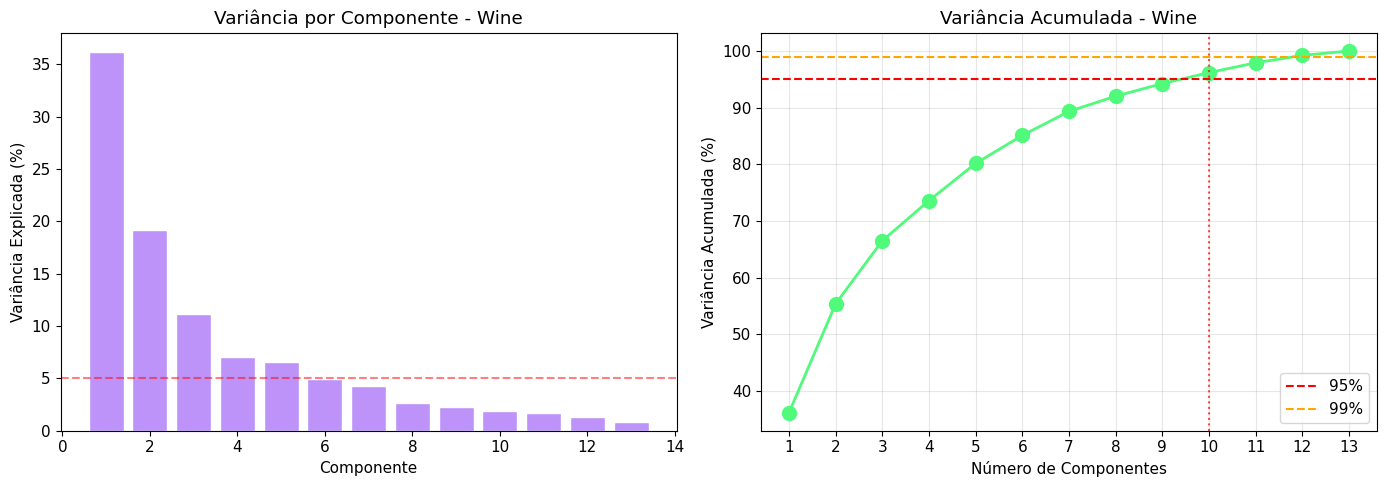

Gráfico salvo: ../graficos/cotovelo_wine.png


In [8]:
# Gráfico de cotovelo com número ótimo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
axes[0].bar(range(1, len(cumsum)+1), pca_full.explained_variance_ratio_ * 100, 
            color='#bd93f9', edgecolor='white')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Variância por Componente - Wine')
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Limiar 5%')

# Cumulativa
axes[1].plot(range(1, len(cumsum)+1), cumsum * 100, 'bo-', 
            markersize=10, linewidth=2, color='#50fa7b')
axes[1].axhline(y=95, color='red', linestyle='--', label='95%')
axes[1].axhline(y=99, color='orange', linestyle='--', label='99%')
axes[1].axvline(x=n_for_95, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Acumulada - Wine')
axes[1].legend()
axes[1].set_xticks(range(1, 14))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/cotovelo_wine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/cotovelo_wine.png")

## 4. Interpretando os Loadings (Contribuição de Features)

In [9]:
# Loadings do PC1 e PC2
loadings = pca_wine.components_  # shape: (n_components, n_features)

print("Loadings do PC1 (maior variância):")
for name, loading in sorted(zip(wine.feature_names, loadings[0]), key=lambda x: abs(x[1]), reverse=True)[:5]:
    print(f"  {name}: {loading:.3f}")

print("\nLoadings do PC2:")
for name, loading in sorted(zip(wine.feature_names, loadings[1]), key=lambda x: abs(x[1]), reverse=True)[:5]:
    print(f"  {name}: {loading:.3f}")

Loadings do PC1 (maior variância):
  flavanoids: 0.423
  total_phenols: 0.395
  od280/od315_of_diluted_wines: 0.376
  proanthocyanins: 0.313
  nonflavanoid_phenols: -0.299

Loadings do PC2:
  color_intensity: 0.530
  alcohol: 0.484
  proline: 0.365
  ash: 0.316
  magnesium: 0.300


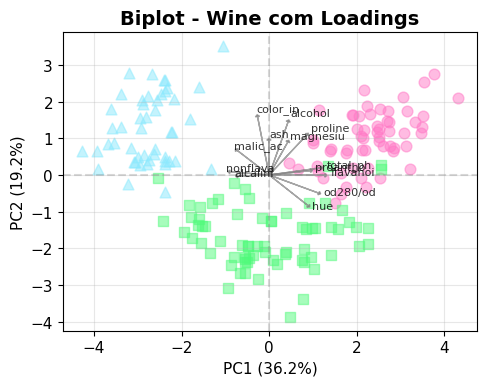

Gráfico salvo: ../graficos/biplot_wine.png


In [11]:
# Biplot simplificado
fig, ax = plt.subplots(figsize=(5, 4))

# Scatter dos dados
for i, (color, marker) in enumerate(zip(['#ff79c6', '#50fa7b', '#8be9fd'], ['o', 's', '^'])):
    mask = y_wine == i
    ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1], c=color, marker=marker, s=60, alpha=0.5)

# Setas dos loadings
scale = 3
for j, name in enumerate(wine.feature_names):
    ax.arrow(0, 0, loadings[0, j] * scale, loadings[1, j] * scale,
             head_width=0.1, head_length=0.05, fc='gray', ec='gray', alpha=0.7)
    ax.text(loadings[0, j] * scale * 1.1, loadings[1, j] * scale * 1.1, 
            name[:8], fontsize=8, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot - Wine com Loadings', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/biplot_wine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/biplot_wine.png")